* You can add as many cells as you need to answer the questions.
* You can also answer any word or math based questions in a markup cell.
* Plots should have labels on the axes, legends if appropriate etc.

# Assignment 1 :  MC Simulations of Estimators of Location and Spread

In [1]:
import numpy as np
import scipy.stats

import matplotlib
import matplotlib.pyplot as plt

# Adjust default font size so that labels are readable in plots
font = {'size': 12}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['figure.figsize'] = [6, 4]
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

For full marks, write the code below as a function or suite of functions that accepts another function (e.g. one that calculates $s^2$ or $s$) as an argument.

## Q1

For the first exercise you will use ``numpy`` and/or ``scipy`` and/or your own functions to test the formula for the estimated sample variance $s^2$.  

1. Do a _Monte Carlo_ (MC) simulation by drawing $M$ samples of $N$ data points, where $M$ is some very large number (like 10000). Each sample of $N$ data points is drawn from a Gaussian distribution with mean $\mu = 0$ and $\sigma^2 = 1$.

2. For each sample, <mark>calculate the _sample_ variance $s^2$</mark> using the standard formula. 
<mark>You can use builtin functions to do this on numpy arrays, or write your own. If the former, read the function docs carefully.</mark>

3. <mark>Save the values of $s^2$ in an array of length $M$</mark>. We are using a MC method to estimate what is called the _sampling distribution_, or, more specifically, the _sampling distribution of the sample variance_.

4. Then <mark>calculate the mean and variance of $s^2$ over all the $M$ MC samples</mark>, i.e the mean and variance of the sampling distribution.

5. Plot the mean $s^2$ (over all $M$ MC samples), $\overline{s^2}$, along with errorbars that show the <mark>_standard error_ in $\overline{s^2}$ (not the standard deviation of $s^2$)</mark>, as a function of $N$ from $N = 2$ to $N = 30$. Plot a line showing the <mark>expected value of $s^2$ for the population</mark>.

6. What is the $\chi^2$ of the simulated data points plotted in 5) compared to the model line? <mark>Is it an acceptable fit?</mark>

7. Based on this Monte Carlo experiment, is the sample variance estimator ($s^2$) unbiased?


### Step 1

In [2]:
def compute_variance_of_sample(data):
    variance = np.var(data, ddof=1)         # ddof = 1 because we are estimating the mean from the data (N-1 factor)
    
    return variance

def estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(function_that_computes_metric, M, N, rng):
    estimates_for_each_sample = np.empty(shape=M)

    for i in range(0,M):
        sample = rng.normal(loc=0,scale=1,size=N)            # N(mu=0,std=1)
        estimates_for_each_sample[i] = function_that_computes_metric(sample)

    return estimates_for_each_sample

def compute_standard_error_of_sample(sample_variance, N):
    standard_error = np.sqrt(sample_variance / N)

    return standard_error

def compute_chi2_of_data(data, model, uncertainty):
    chi2 = np.sum( ( (data - model)/(uncertainty) )**2 )

    return chi2  

def compute_reduced_chi2(chi2, dof):
    rdchi2 = chi2 / dof
    
    return rdchi2   


In [3]:
M = 10000       # Number of samples to be drawn, we draw M times a sample containing N data points taken from N~N(0,1)
N_array = np.linspace(2, 30, num=29, dtype=int)

rng = np.random.default_rng()

### Step 2 and 3 

In [ ]:
estimates_of_variance = []          # holds the variances estimated by each individual 10000 runs with N data points, for each N                            # shape (29, 10000)

for N in N_array:
    variance_estimates = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_variance_of_sample, M, N, rng)      # shape (10000,), contains 10000 variance values for a given N 
    estimates_of_variance.append(variance_estimates)

print(estimates_of_variance)        # array of 10000 s2 values for each N

[array([0.36926933, 0.00927066, 0.25233344, ..., 0.26973211, 0.8894306 ,
       0.13387118], shape=(10000,)), array([0.12507061, 4.85884291, 2.09485948, ..., 0.58463022, 0.52485137,
       0.90776384], shape=(10000,)), array([1.23796913, 1.3890033 , 0.85396043, ..., 0.31617956, 1.25293078,
       0.61962663], shape=(10000,)), array([0.67441101, 0.5397591 , 2.23215747, ..., 0.68338886, 2.87789265,
       0.40111106], shape=(10000,)), array([0.20884942, 1.07596594, 0.18234633, ..., 1.73516074, 0.97129655,
       0.71235978], shape=(10000,)), array([0.78314983, 0.94950722, 1.1183762 , ..., 2.30139367, 1.73987948,
       0.98587805], shape=(10000,)), array([0.5841061 , 0.64136759, 1.44969252, ..., 1.44471162, 1.67050145,
       0.24893048], shape=(10000,)), array([0.71321402, 1.87943121, 0.71491998, ..., 0.39619634, 1.16586953,
       0.37613192], shape=(10000,)), array([0.20915501, 1.6060937 , 0.33857159, ..., 0.58625981, 1.31687612,
       1.68959538], shape=(10000,)), array([0.37279147,

### Step 4

In [5]:
means_of_estimates_of_variance = []      # holds the mean of all 10000 variances computed for a given N                  # shape (29, 1)
for estimates in estimates_of_variance: 
    mean = np.mean(estimates)           # computes the mean of all 10000 variances          # shape (1,)
    means_of_estimates_of_variance.append(mean)   

variances_of_estimates_of_variance = []  # holds the variance of all the 10000 variances computed for a given N          # shape (29, 1)
for estimates in estimates_of_variance:
    var = np.var(estimates, ddof=1)                 # Bessel Correction Factor
    variances_of_estimates_of_variance.append(var)

print(means_of_estimates_of_variance)            # array of the avg of all 10000 s2 values for a given N     
print()
print(variances_of_estimates_of_variance)        # array of the s2 of all 10000 s2 values for a given N 

[np.float64(0.9960151035986085), np.float64(0.9894199060293322), np.float64(1.0008693636390278), np.float64(0.9974813784757529), np.float64(0.9967922183853636), np.float64(0.9996749762622505), np.float64(0.9968195319480107), np.float64(0.9940343871351308), np.float64(0.9981939694951311), np.float64(0.9902603117758366), np.float64(1.0042768050014936), np.float64(1.004188381944685), np.float64(0.9992208873994057), np.float64(0.9934985436637535), np.float64(1.003182898957142), np.float64(1.0010489429468719), np.float64(1.004222983744092), np.float64(0.994455058424194), np.float64(0.9988260817857023), np.float64(1.0042417537657116), np.float64(1.0033670808949722), np.float64(0.9969668784716404), np.float64(1.0016824770356538), np.float64(1.0027416304733925), np.float64(1.0012009846369099), np.float64(0.9991604959802564), np.float64(1.004463215310848), np.float64(1.0021022033220022), np.float64(0.9993318774559823)]

[np.float64(2.009483516019947), np.float64(0.964207876418583), np.float64(0

### Step 5

standard error in the mean is:

$$
\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}} = \sqrt{ \frac{\sigma^2}{N} }
$$

but the population variance $\sigma^2$ is unknown, so we estimate the standard error by substituting the sample variance $s^2$

\begin{equation*}
    \sigma_{\bar{x}} = \sqrt{ \frac{s^2}{N} }
\end{equation*}

so that the standard error of the mean variance with M sample size is 

\begin{equation*}
    \sigma_{\bar{s^2}} = \sqrt{ \frac{\rm var(s^2)}{M} }
\end{equation*}

In [6]:
standard_errors_of_means_of_estimates_of_variance = []              # holds the stderr for each mean        # shape (29, 1)

for var in variances_of_estimates_of_variance:
    stderr = compute_standard_error_of_sample(var, N=M)             # computes the std err in the mean of the variances -> we computed the avg of all 10000 s2 values so N=10000
    standard_errors_of_means_of_estimates_of_variance.append(stderr)

print(standard_errors_of_means_of_estimates_of_variance)            # array of stderr for each mean of variance     # shape (29 , 1)

[np.float64(0.014175625263176037), np.float64(0.00981940872160123), np.float64(0.008106355021160399), np.float64(0.007057259670911789), np.float64(0.006257214732184566), np.float64(0.005765519208596848), np.float64(0.0053400643921540855), np.float64(0.004973939627236588), np.float64(0.004669367357866155), np.float64(0.004456794001649451), np.float64(0.00422794901331977), np.float64(0.0041139710044589), np.float64(0.003899089465379522), np.float64(0.0037718280214183845), np.float64(0.003632156803850106), np.float64(0.0035613926857359433), np.float64(0.003441415230711677), np.float64(0.0033346153582091463), np.float64(0.003267774378245198), np.float64(0.0031992217635697594), np.float64(0.0030843202582559095), np.float64(0.0029975091981103855), np.float64(0.0029369956538675894), np.float64(0.002902631795202159), np.float64(0.002847260231398628), np.float64(0.002754016482726344), np.float64(0.0027370080750615255), np.float64(0.002700865896696934), np.float64(0.0026043819123766796)]


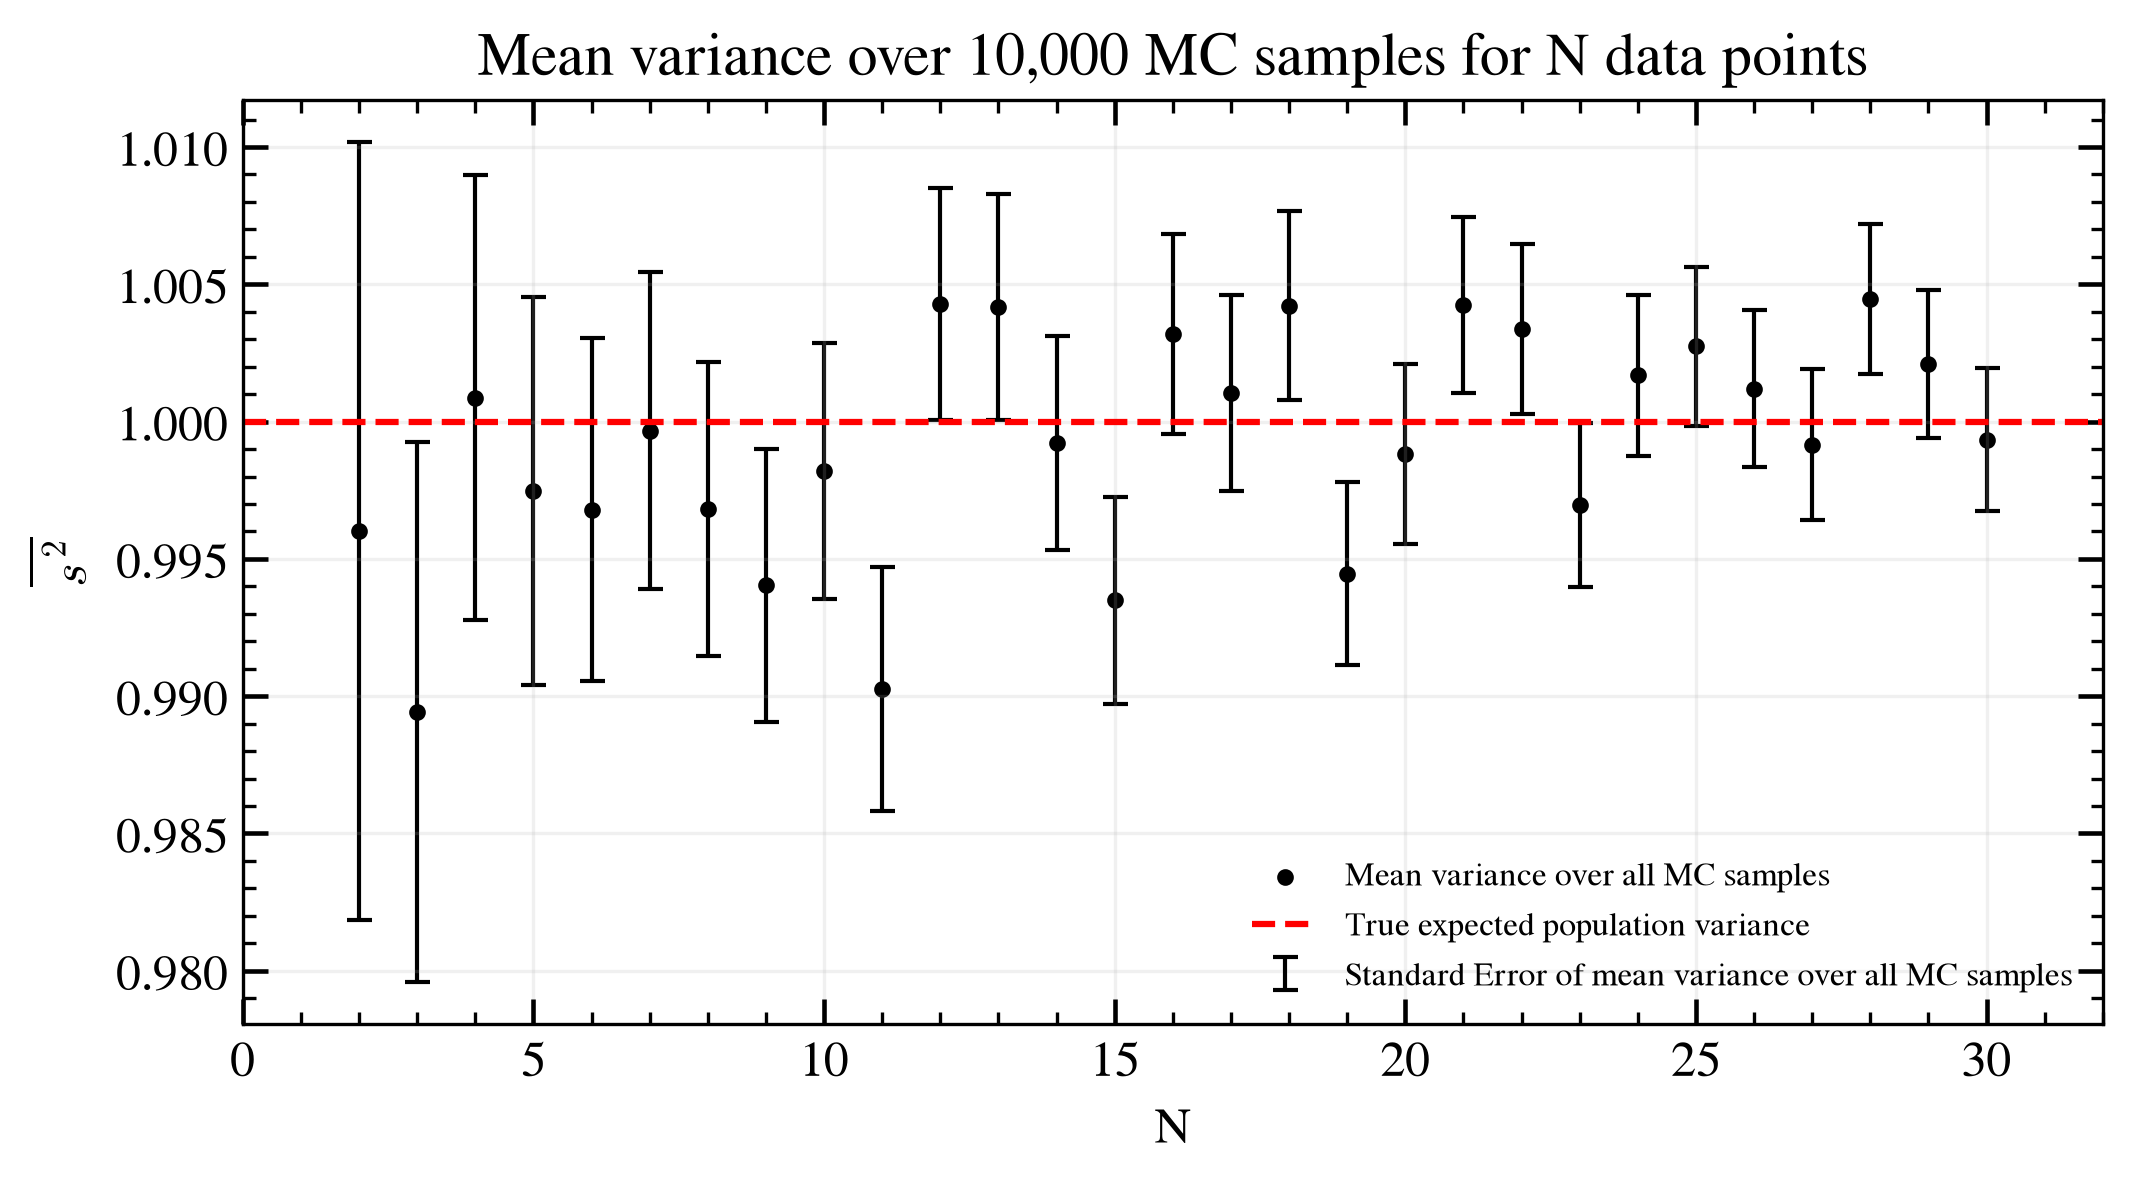

In [7]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('N')
ax.set_ylabel(r'$\overline{s^2}$')
ax.set_title("Mean variance over 10,000 MC samples for N data points")
ax.set_xlim(0,32)
# ax.set_ylim(0.95,1.05)

ax.scatter(N_array, means_of_estimates_of_variance, marker='.', label="Mean variance over all MC samples", color='black')

ax.errorbar(N_array, means_of_estimates_of_variance, 
    yerr=standard_errors_of_means_of_estimates_of_variance,
    fmt="none",
    capsize=3,
    lw = 1.0, 
    label="Standard Error of mean variance over all MC samples",
    zorder= -3, 
    color = 'black'
)

ax.axhline(y=1, color= 'red', ls='dashed', label = 'True expected population variance')    # true E[s2] for normal ~N(0,1) is 1

ax.legend(frameon=False, fontsize=8, loc='best')

### Step 6

The $\chi^2$ relative to y = 1 is given by 

\begin{equation*}

\chi^2 = \sum_i^N \frac{(y_i - f_i)^2}{\sigma_i^2}

\end{equation*}
where $y_i$ is measured and $f_i$ is the model, $\sigma_i$ is the uncertainty in $y_i$. 

In our case, $y_i = \overline{s^2}$ , $f_i = 1$, and $\sigma_i=$ standard error of $\overline{s^2}$

\begin{equation*}

\chi^2 = \sum_2^{30} \bigg( \frac{\overline{s^2} - 1}{SE[\overline{s^2}]} \bigg)^2

\end{equation*}

In [8]:
data = np.asarray(means_of_estimates_of_variance)
model = np.ones_like(data)
unc = np.asarray(standard_errors_of_means_of_estimates_of_variance)

chi2_of_means_of_estimates_of_variance = compute_chi2_of_data(data,model,unc)           #gives a singular chi2 value for the fit to the data

dof = len(N_array) - 0                   # dof = N - numbers of parameters = 29 since we have 29 data points and no parameters (model is a constant)

print(f"chi2: {chi2_of_means_of_estimates_of_variance}")
print(f"reduced chi2: {compute_reduced_chi2(chi2_of_means_of_estimates_of_variance, dof=dof)}")        

pval = scipy.stats.chi2.sf(chi2_of_means_of_estimates_of_variance, dof)
print(f"p value: {pval}") 


chi2: 27.484287551287235
reduced chi2: 0.9477340534926633
p value: 0.5455940317752936


In [9]:
# Goodness of fit
if pval < 0.05:         # reject H0 that data and model are the same
    print(f'This is not a good fit. With a {pval:2f} < 0.05, we must reject the model (that the data and the model are equal).')

if pval >= 0.05:         # reject H0 that data and model are the same
    print(
        f'This is a good fit. With a {pval:2f} >= 0.05, we do not have enough evidence to reject the prediction that the data and the model are equal.' ,
        f'\nThus we can say this is a statistically acceptable fit and that the simulated results are consistent with it.'
    )

This is a good fit. With a 0.545594 >= 0.05, we do not have enough evidence to reject the prediction that the data and the model are equal. 
Thus we can say this is a statistically acceptable fit and that the simulated results are consistent with it.


### Step 7

Given that the MC mean of the sample variance is consistent with the true population mean of $1$ across $N = 2,3,...,30$ sample sizes and that the chi-squared did not yield any significant disagreement with this prediction, I claim that based on this MC experiment that the estimator is <b>unbiased</b> since its measured metric averaged over a large sample size did not deviate from the true population value. 

## Q2

In a variant of the above exercises, suppose for each sample of size $N$ drawn from a normal distribution, you calculate both the _sample_ mean $\bar{x}$ and the _sample_ variance $s^2$. Then define the statistic:
$$
Z = \frac{\bar{x}}{s/\sqrt{N}}
$$

a) For $N=5$, $M = 100,000$, plot a histogram of $Z$. Overplot a normal distribution.

b) Repeat for $N=100$.


c)  Is it the overplotted normal distribution [in parts a) and b)] a good fit? If not, why and in what way does it differ?

### Part a)

In [10]:
N = 5
M = 100000

def compute_Z(data):
    sample_mean = np.mean(data)
    sample_variance = compute_variance_of_sample(data)
    N = len(data)
    
    Z = sample_mean / (np.sqrt(sample_variance / N))

    return Z

In [11]:
Z_estimates_for_N_5 = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_Z, M=M, N=N, rng=rng)       # array of 100000 Z values for N = 5

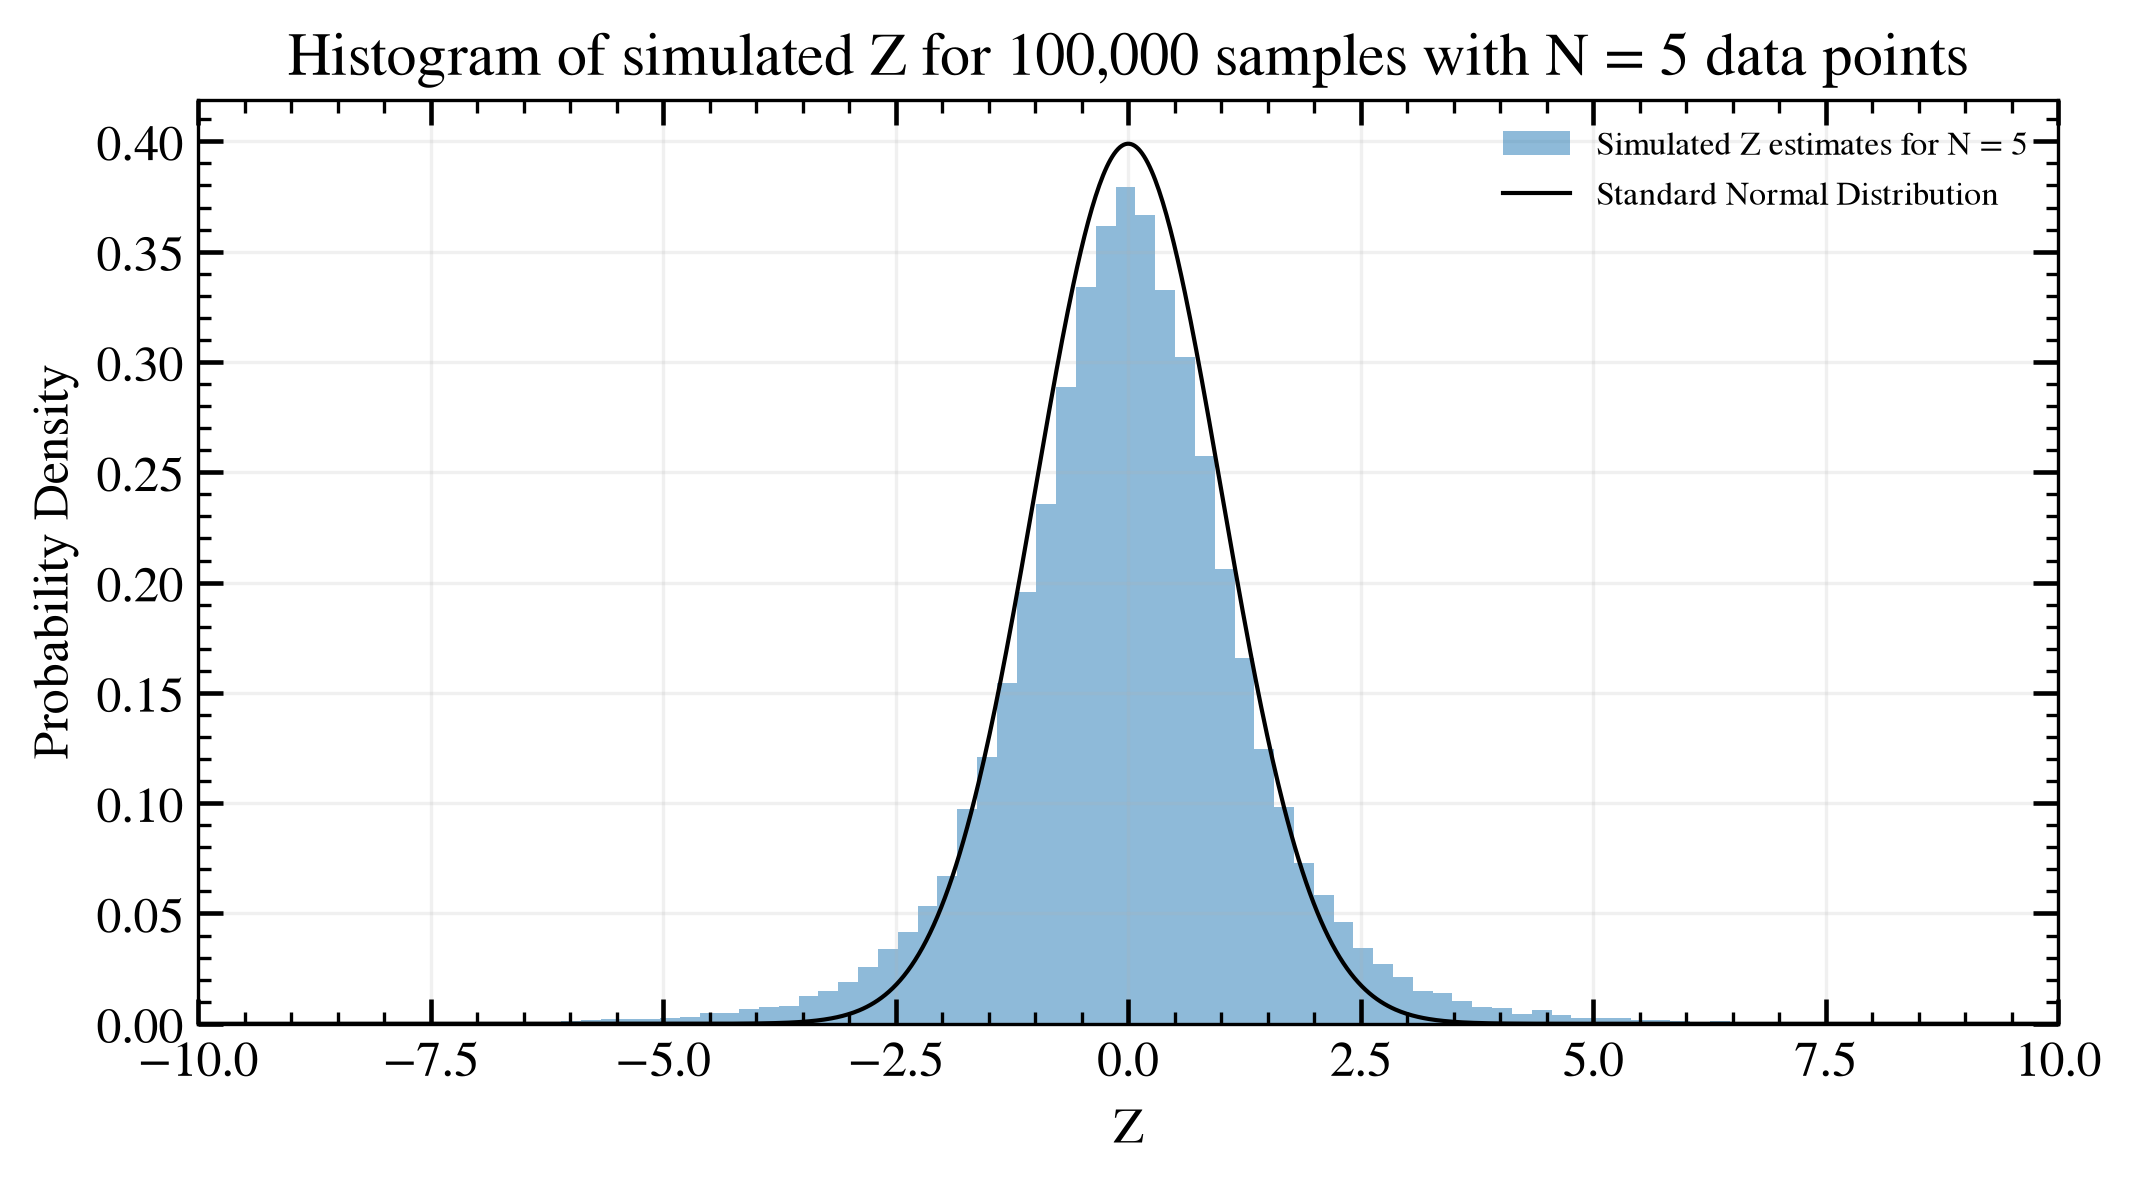

In [12]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

z_space = np.linspace(-10,10,1000)
N01 = scipy.stats.norm.pdf(z_space, loc=0, scale=1)       # Normal distr with mu = 0 and std = 1

ax.hist(Z_estimates_for_N_5, density=True, histtype='stepfilled', alpha=0.5, label='Simulated Z estimates for N = 5', bins=200)
ax.plot(z_space, N01, 'k-', lw=1, label='Standard Normal Distribution')

ax.set_xlabel('Z')
ax.set_ylabel('Probability Density')
ax.set_title("Histogram of simulated Z for 100,000 samples with N = 5 data points")
ax.set_xlim(z_space[0],z_space[-1])
# ax.set_ylim(0,1)
ax.legend(frameon=False, fontsize=8, loc='best')

### Part b)

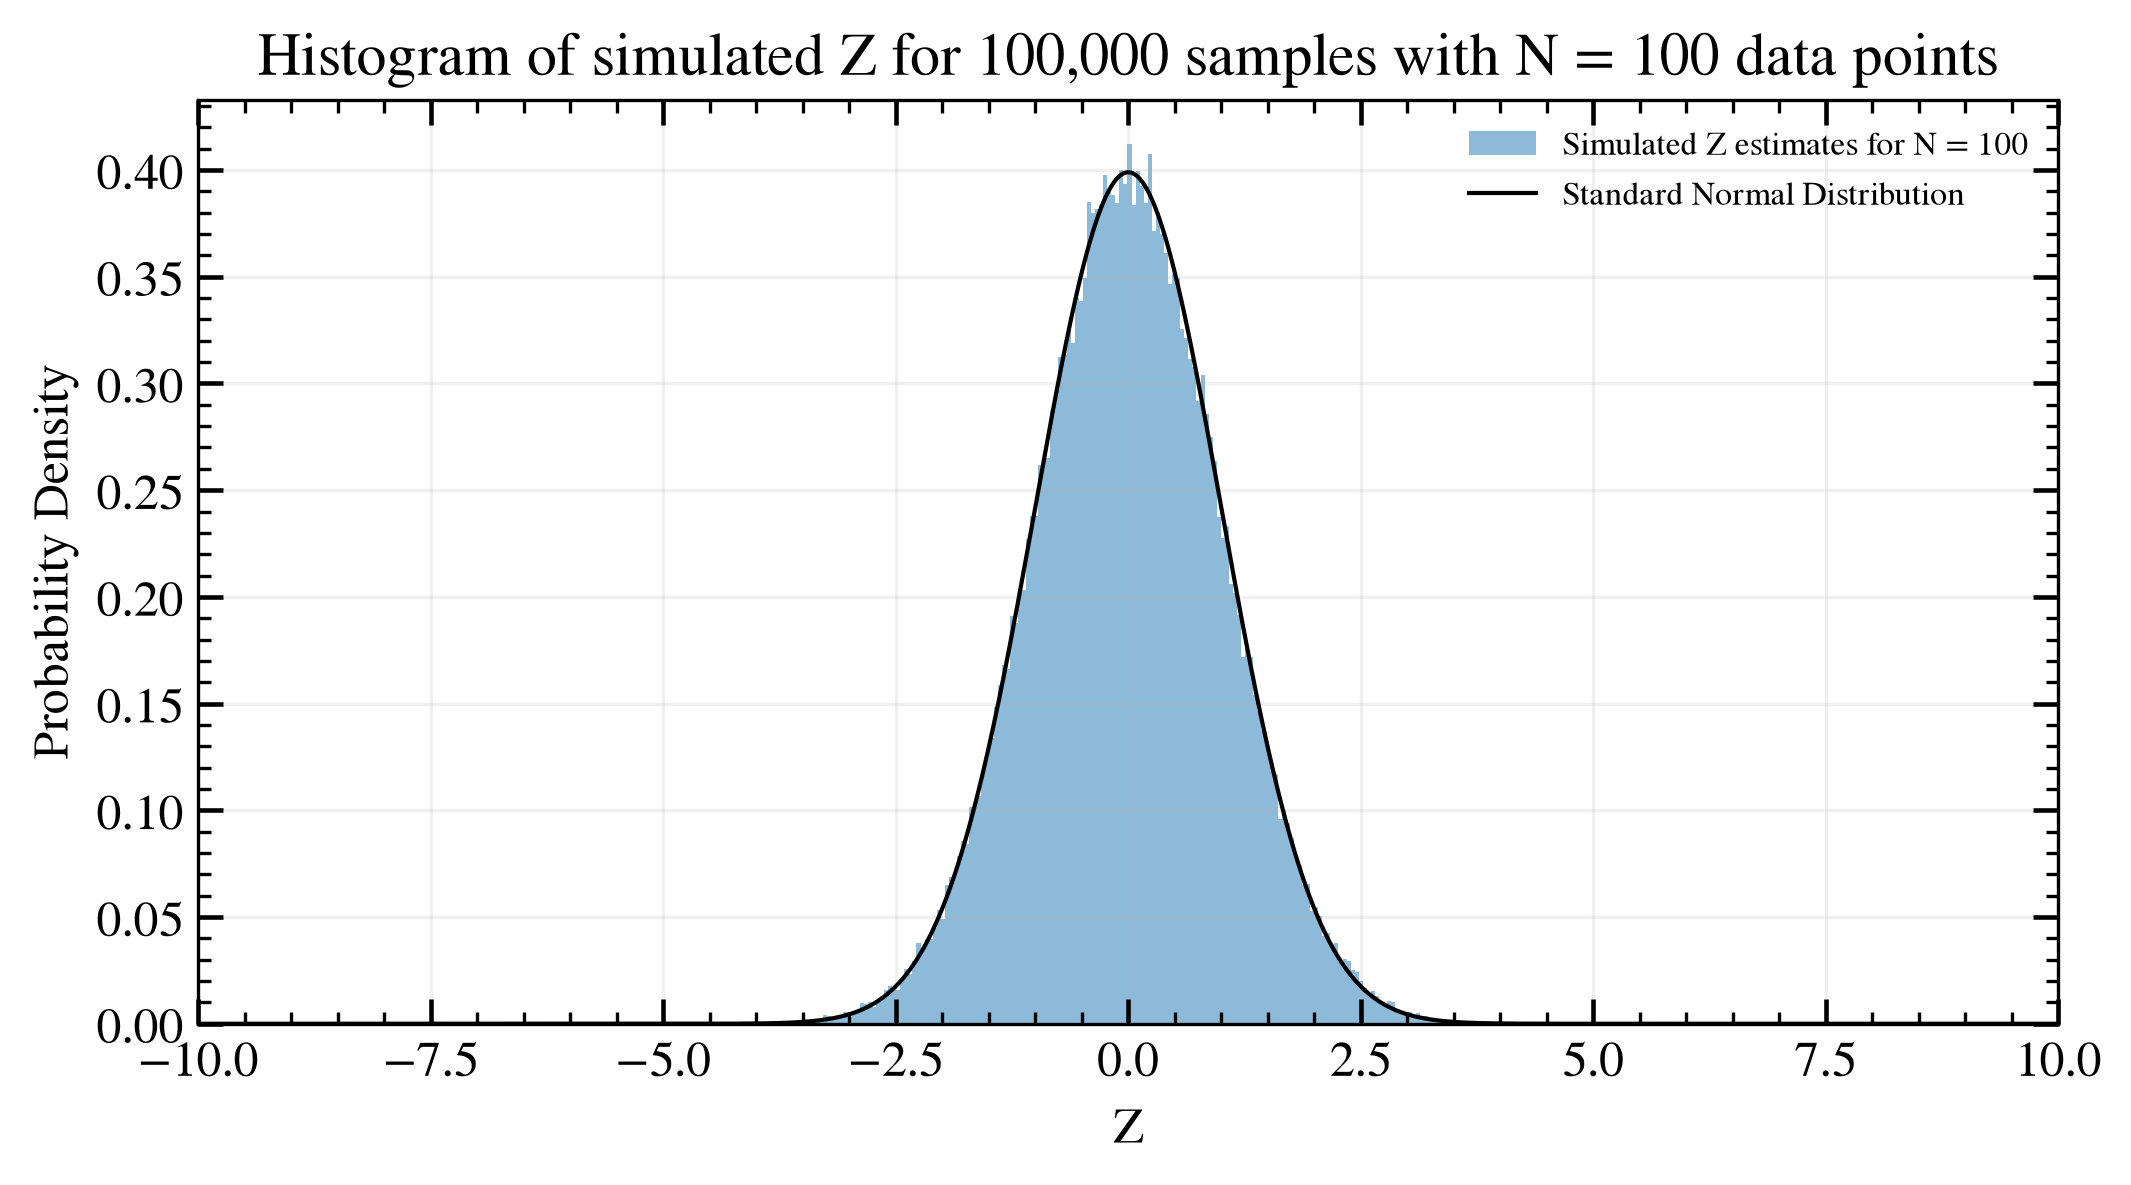

In [13]:
N = 100
M = 100000

Z_estimates_for_N_100 = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_Z, M=M, N=N, rng=rng)       # array of 100000 Z values for N = 100

import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

z_space = np.linspace(-10,10,1000)
N01 = scipy.stats.norm.pdf(z_space, loc=0, scale=1)       # Normal distr with mu = 0 and std = 1

ax.hist(Z_estimates_for_N_100, density=True, histtype='stepfilled', alpha=0.5, label='Simulated Z estimates for N = 100', bins=200)
ax.plot(z_space, N01, 'k-', lw=1, label='Standard Normal Distribution')

ax.set_xlabel('Z')
ax.set_ylabel('Probability Density')
ax.set_title("Histogram of simulated Z for 100,000 samples with N = 100 data points")
ax.set_xlim(z_space[0],z_space[-1])
# ax.set_ylim(0,1)
ax.legend(frameon=False, fontsize=8, loc='best')

### Part c)

I would say that in part a), the overplotted normal distribution is <b>not a good fit</b>. This is because it overestimates the probability density near the peak at zero and underestimates the probability density in the tails away from $z = 0$.

In part b) however, the overplotted normal distribution is <b>indeed a good fit</b> as it closely follows the underlying probability density without over or underestimating near the peak and in the tails. 

## Q3

Now repeat Q1, but in steps 2-6 replace the sample variance $s^2$ with its square root, the sample standard deviation $s$.

Are the results the same as for $s^2$? Explain.

In [14]:
def compute_std_of_sample(data):
    std = np.std(data, ddof=1)
    
    return std 

### Step 1 (reset M and N)

In [15]:
M = 10000       # Number of samples to be drawn, we draw M times a sample containing N data points taken from N~N(0,1)
N_array = np.linspace(2, 30, num=29, dtype=int)

### Step 2 and 3

In [16]:
estimates_of_std = []          # holds the std estimated by each individual 10000 runs with N data points, for each N                            # shape (29, 10000)

for N in N_array:
    std_estimates = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_std_of_sample, M, N, rng)      # shape (10000,), contains 10000 std values for a given N 
    estimates_of_std.append(std_estimates)

print(estimates_of_std)        # array of 10000 s values for each N

[array([0.09264995, 0.87609323, 0.40872272, ..., 0.51886371, 0.54550297,
       0.46901346], shape=(10000,)), array([1.50976099, 0.08857179, 0.57261148, ..., 1.13866774, 1.10282642,
       1.13622627], shape=(10000,)), array([1.15310551, 1.25292556, 0.40777331, ..., 0.77024845, 1.38361824,
       0.33404072], shape=(10000,)), array([1.23041818, 1.39727607, 1.16873916, ..., 0.51810156, 1.55168283,
       0.82319315], shape=(10000,)), array([1.28940045, 1.10914196, 1.11208258, ..., 0.72055281, 0.86899791,
       2.20396691], shape=(10000,)), array([0.91447307, 1.00030461, 1.6383965 , ..., 0.97838953, 0.5125885 ,
       1.10544305], shape=(10000,)), array([0.82231763, 0.62433132, 1.19998325, ..., 0.86112575, 0.49306496,
       0.68049721], shape=(10000,)), array([1.09794432, 1.01855025, 1.08107796, ..., 0.88126295, 1.17910632,
       1.13456867], shape=(10000,)), array([1.13855053, 0.69558059, 0.7309358 , ..., 0.99759131, 1.02329335,
       0.59926561], shape=(10000,)), array([0.85846654,

### Step 4

In [17]:
means_of_estimates_of_std = []      # holds the mean of all 10000 std computed for a given N                  # shape (29, 1)
for estimates in estimates_of_std: 
    mean = np.mean(estimates)           # computes the mean of all 10000 std          # shape (1,)
    means_of_estimates_of_std.append(mean)   

variances_of_estimates_of_std = []  # holds the variance of all the 10000 std computed for a given N          # shape (29, 1)
for estimates in estimates_of_std:
    var = np.var(estimates, ddof=1)                 # Bessel Correction Factor
    variances_of_estimates_of_std.append(var)

print(means_of_estimates_of_std)            # array of the avg of all 10000 s values for a given N     
print()
print(variances_of_estimates_of_std)        # array of the s2 of all 10000 s values for a given N 

[np.float64(0.7928527114481282), np.float64(0.8815215707388037), np.float64(0.9139965971073454), np.float64(0.9442748249044538), np.float64(0.950809091623842), np.float64(0.9545310932386152), np.float64(0.965874486736618), np.float64(0.970175139840671), np.float64(0.9720447567157389), np.float64(0.9740696007938455), np.float64(0.9814762088520407), np.float64(0.9771521867497899), np.float64(0.9790103696387782), np.float64(0.985104367638315), np.float64(0.9827106379303426), np.float64(0.9861233867718918), np.float64(0.9834481393759), np.float64(0.9875153135013411), np.float64(0.9872097032940422), np.float64(0.9889216445288763), np.float64(0.9884056433357206), np.float64(0.9924815296781989), np.float64(0.9910512658252614), np.float64(0.9880877812621085), np.float64(0.9888925028024641), np.float64(0.989167765814413), np.float64(0.9904879048604324), np.float64(0.9908772255117292), np.float64(0.9894459690865038)]

[np.float64(0.35987134835347445), np.float64(0.21087363193759226), np.float64(

### Step 5

In [18]:
standard_errors_of_means_of_estimates_of_std = []              # holds the stderr for each mean        # shape (29, 1)

for var in variances_of_estimates_of_std:
    stderr = compute_standard_error_of_sample(var, N=M)             # computes the std err in the mean of the std -> we computed the avg of all 10000 s values so N=10000
    standard_errors_of_means_of_estimates_of_std.append(stderr)

print(standard_errors_of_means_of_estimates_of_std)            # array of stderr for each mean of std     # shape (29 , 1)

[np.float64(0.005998927807145827), np.float64(0.004592097907684376), np.float64(0.0039010350440713284), np.float64(0.003416958393445171), np.float64(0.0030584023196132326), np.float64(0.0028447673163714167), np.float64(0.002614030981941362), np.float64(0.0024537434690702228), np.float64(0.0023071636974712224), np.float64(0.0022107378793880376), np.float64(0.002108108388186453), np.float64(0.0020286204381829804), np.float64(0.0019361705031586984), np.float64(0.0018904614668390199), np.float64(0.0018279838837248785), np.float64(0.0017587411052485834), np.float64(0.00169389577465397), np.float64(0.0016701402710841888), np.float64(0.0016073250269689246), np.float64(0.0015631875610114694), np.float64(0.001536200887712159), np.float64(0.0015076954768092244), np.float64(0.0014911082571438024), np.float64(0.0014321350772338653), np.float64(0.0013986665884100293), np.float64(0.0013626401697879843), np.float64(0.0013604908074632716), np.float64(0.0013373197614293343), np.float64(0.00130045990144

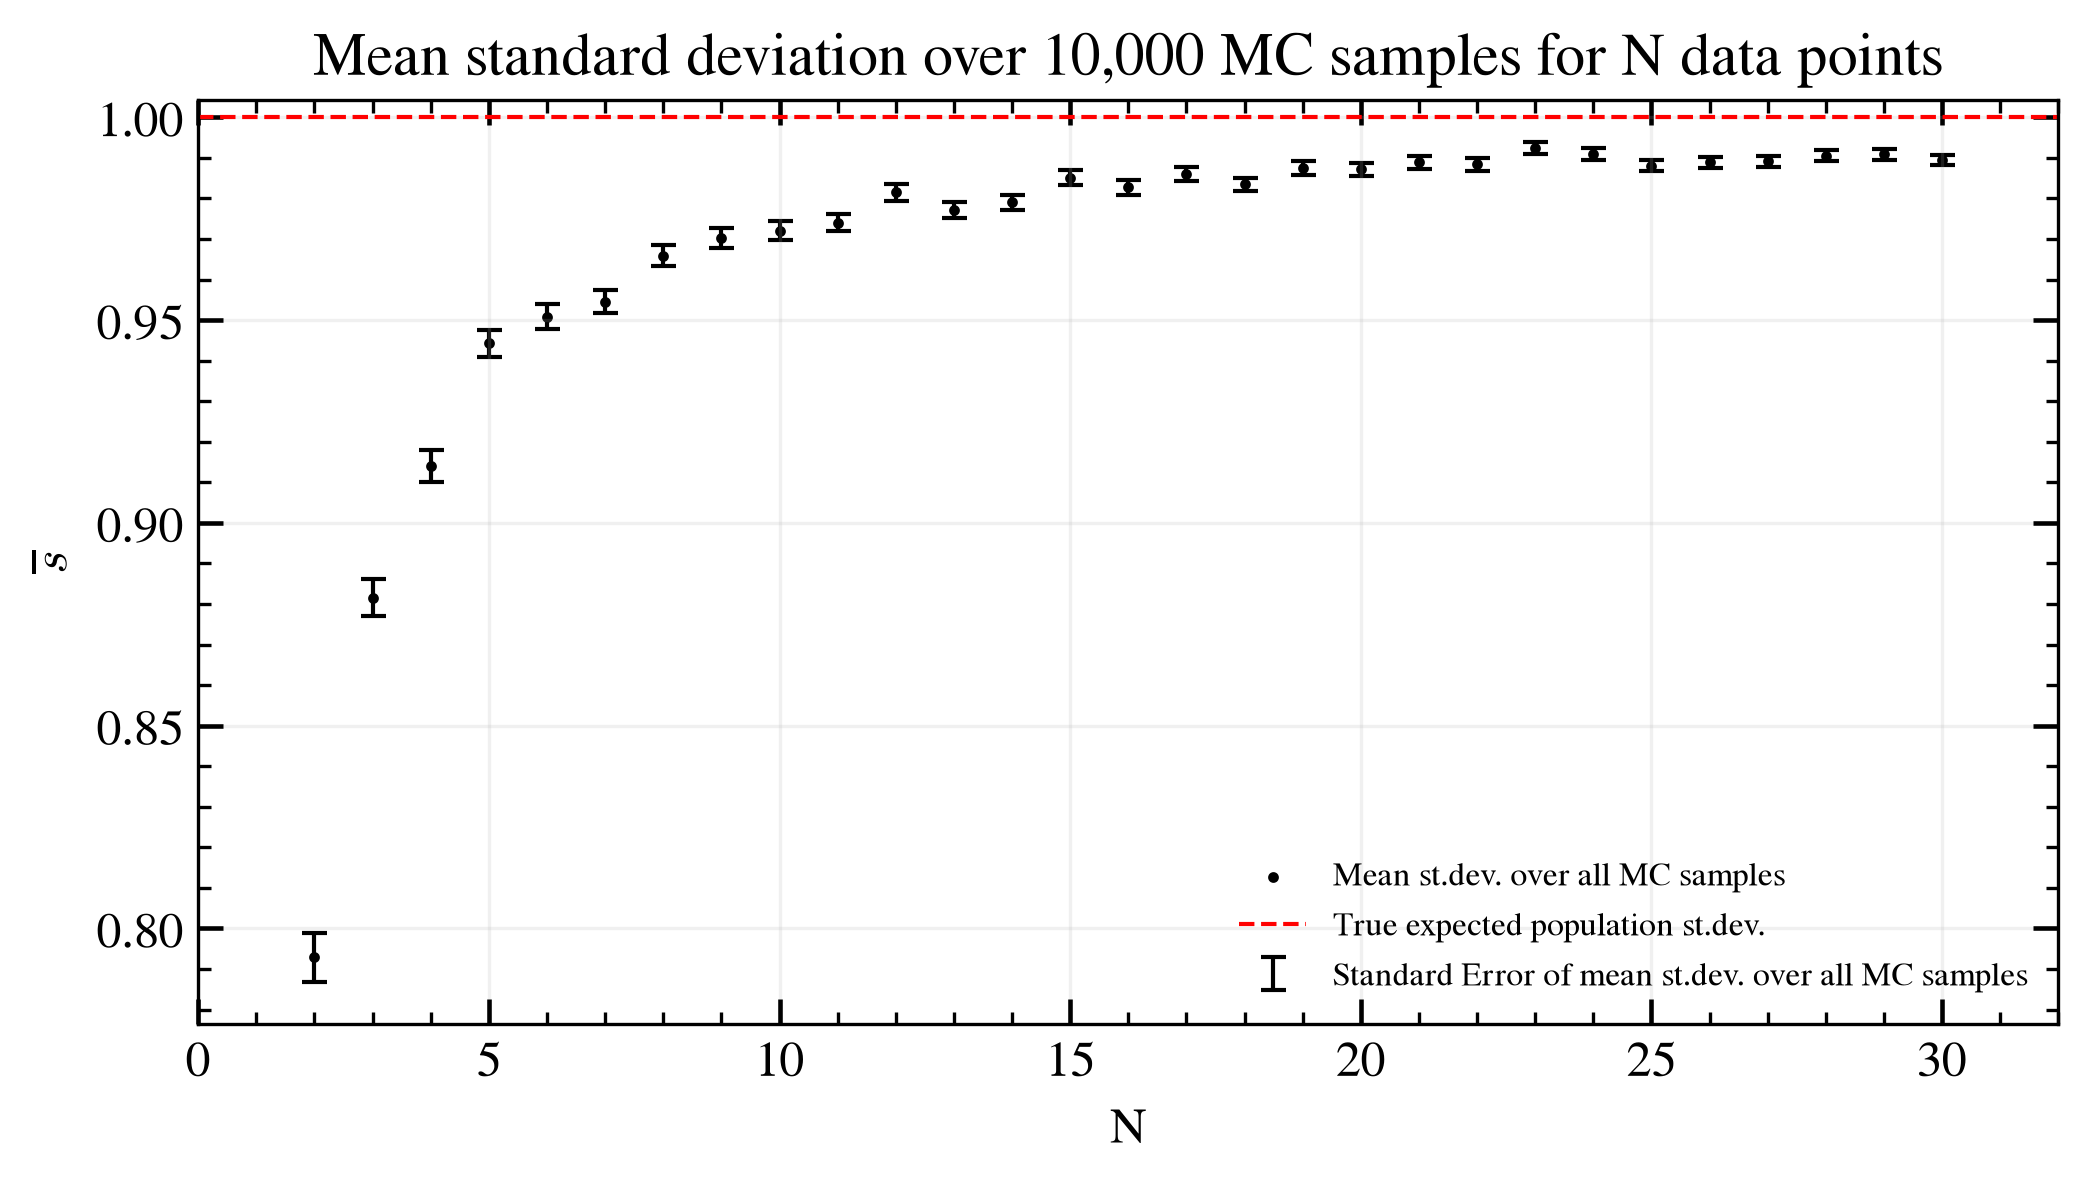

In [32]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('N')
ax.set_ylabel(r'$\overline{s}$')
ax.set_title("Mean standard deviation over 10,000 MC samples for N data points")
ax.set_xlim(0,32)
# ax.set_ylim(0.95,1.05)

ax.scatter(N_array, means_of_estimates_of_std, marker='.', s = 10, label="Mean st.dev. over all MC samples", color='black')

ax.errorbar(N_array, means_of_estimates_of_std, 
    yerr=standard_errors_of_means_of_estimates_of_std,
    fmt="none",
    capsize=3,
    lw = 1.0, 
    label="Standard Error of mean st.dev. over all MC samples",
    zorder= -3, 
    color = 'black'
)

ax.axhline(y=1, color= 'red', ls='dashed', label = 'True expected population st.dev.', lw = 1.0)    # true E[s] for normal ~N(0,1) is 1

ax.legend(frameon=False, fontsize=8, loc='best')

## Q4

Repeat Q1 but calculate the sample _median_ instead of the sample variance.

Then calculate the mean and variance of the median over all the $M$ MC samples, i.e the mean and variance of the sampling distribution.

Plot the __ratio__ of the MC-estimated variance of the _median_ to the theoretical expectation for variance of the _mean_, as a function of $N$ from 5 to 500 (in steps of 20 or 25, say).

b) What is the asymptotic of this ratio for large $N$? Discuss the pros and cons of medians vs. means for the general case (i.e. the underlying distribution could be Gaussian or not).